# Task 1: Data Preprocessing & Cleaning
**Internship:** Thiranex Data Science Internship  
**Project:** Data Preprocessing & Visual Reporting  
**Focus:** Missing Values, Duplicates, Outlier Handling, Categorical Encoding & Feature Scaling  
**Dataset:** Real-World E-Commerce Transactions Dataset (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Load raw dataset
data_path = 'data/raw_ecommerce_data.csv' if os.path.exists('data/raw_ecommerce_data.csv') else 'data/raw_superstore_sales.csv'
if not os.path.exists(data_path):
    data_path = 'Task-01-Data-Cleaning-and-Visualization/data/raw_ecommerce_data.csv'
    
df = pd.read_csv(data_path)
print("Initial Dataset Shape:", df.shape)
df.head()

Initial Dataset Shape: (25000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1. Data Inspection & Missing Value Detection
Checking dataset shape, missing values per column, and duplicate records.

In [2]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("--- Missing Values ---")
display(missing_df)

print(f"\nExact Duplicate Rows Detected: {df.duplicated().sum()}")
print("\nColumn Data Types:\n", df.dtypes)

--- Missing Values ---


,Missing Count,Percentage (%)
CustomerID,8944,35.776
Description,111,0.444



Exact Duplicate Rows Detected: 352

Column Data Types:
 InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


### 2. Handling Duplicate Records
Identifying and dropping exact duplicate rows to maintain data integrity.

In [3]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")
print(f"New Dataset Shape: {df.shape}")

Removed 352 duplicate rows.
New Dataset Shape: (24648, 8)


### 3. Handling Missing Values & Type Conversion
- Imputing missing `Description` with `'Unknown'`.
- Imputing missing `CustomerID` with `0` (representing Guest / Unregistered users) and converting to integer.
- Converting `InvoiceDate` to standard `datetime`.
- Filtering out invalid transactions (negative quantities from order cancellations and non-positive prices).

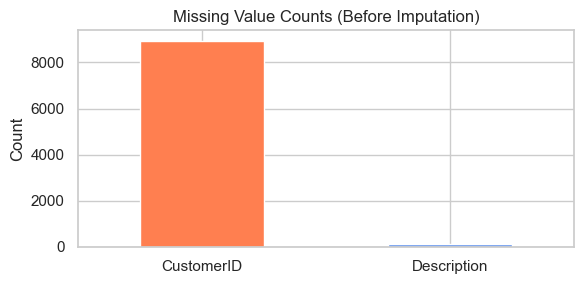

Remaining Missing Values: 0
Shape after Missing Value Handling & Cleansing: (24078, 8)


In [4]:
# Visual report: Missing values before imputation
plt.figure(figsize=(6, 3))
missing_df['Missing Count'].plot(kind='bar', color=['coral', 'cornflowerblue'])
plt.title('Missing Value Counts (Before Imputation)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Impute missing values
df['Description'] = df['Description'].fillna('Unknown')
df['CustomerID'] = df['CustomerID'].fillna(0).astype(int)

# Convert dates & remove invalid/cancelled transactions
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Remaining Missing Values: {df.isnull().sum().sum()}")
print(f"Shape after Missing Value Handling & Cleansing: {df.shape}")

### 4. Outlier Detection & Treatment (IQR Method)
Detecting extreme outliers in numerical columns (`Quantity` and `UnitPrice`) using the Interquartile Range (IQR) method and treating them by capping at the 1st and 99th percentiles.

Quantity Outliers: 2325 (9.7%) | Normal Range: [-6.50, 13.50]
UnitPrice Outliers: 2447 (10.2%) | Normal Range: [-2.75, 8.45]


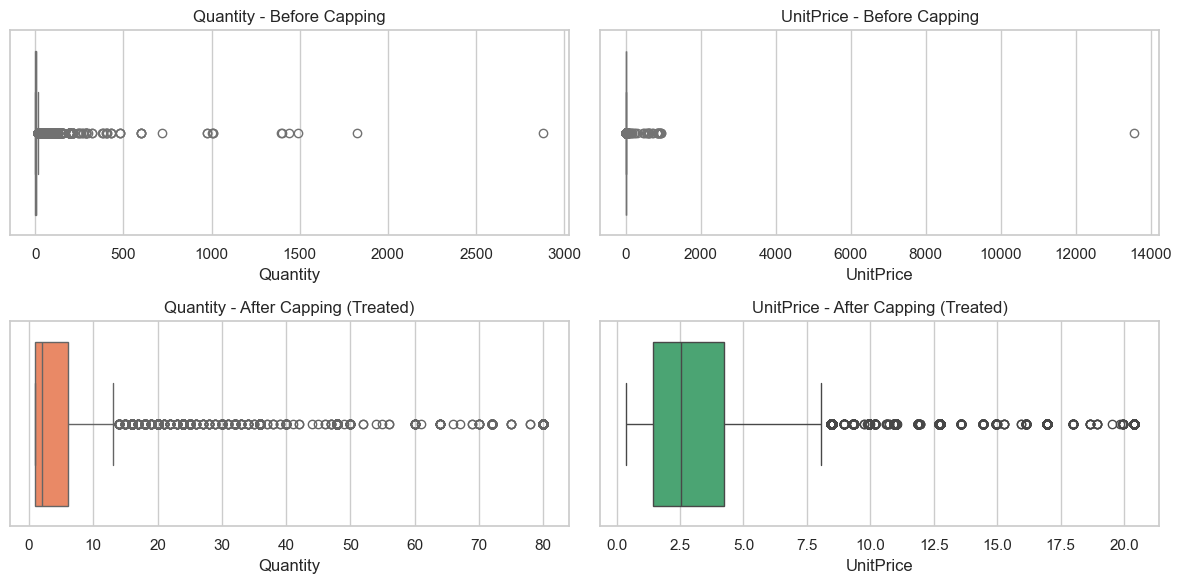

In [5]:
# Outlier detection using IQR
for col in ['Quantity', 'UnitPrice']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%) | Normal Range: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Visual Report: Boxplots Before vs After Capping
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Before capping
sns.boxplot(x=df['Quantity'], ax=axes[0, 0], color='lightsalmon')
axes[0, 0].set_title('Quantity - Before Capping')

sns.boxplot(x=df['UnitPrice'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('UnitPrice - Before Capping')

# Treatment: Capping at 1st and 99th percentiles
df['Quantity'] = df['Quantity'].clip(lower=df['Quantity'].quantile(0.01), upper=df['Quantity'].quantile(0.99))
df['UnitPrice'] = df['UnitPrice'].clip(lower=df['UnitPrice'].quantile(0.01), upper=df['UnitPrice'].quantile(0.99))

# After capping
sns.boxplot(x=df['Quantity'], ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Quantity - After Capping (Treated)')

sns.boxplot(x=df['UnitPrice'], ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('UnitPrice - After Capping (Treated)')

plt.tight_layout()
plt.show()

### 5. Categorical Encoding
Encoding categorical feature `Country` into numerical format using One-Hot Encoding (`pd.get_dummies`) for the top geographical segments.

In [6]:
# Group low-frequency countries into 'Other'
top_countries = df['Country'].value_counts().nlargest(4).index
df['Country_Grouped'] = df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# One-hot encode Country
df = pd.get_dummies(df, columns=['Country_Grouped'], drop_first=True, dtype=int)
print("One-Hot Encoded Features Added:")
print([col for col in df.columns if 'Country_Grouped' in col])
df.head(3)

One-Hot Encoded Features Added:
['Country_Grouped_France', 'Country_Grouped_Germany', 'Country_Grouped_Other', 'Country_Grouped_United Kingdom']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_Grouped_France,Country_Grouped_Germany,Country_Grouped_Other,Country_Grouped_United Kingdom
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,0,0,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,0,0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,0,0,1


### 6. Feature Scaling (StandardScaler)
Standardizing numerical features (`Quantity` and `UnitPrice`) to zero mean and unit variance using `StandardScaler`.

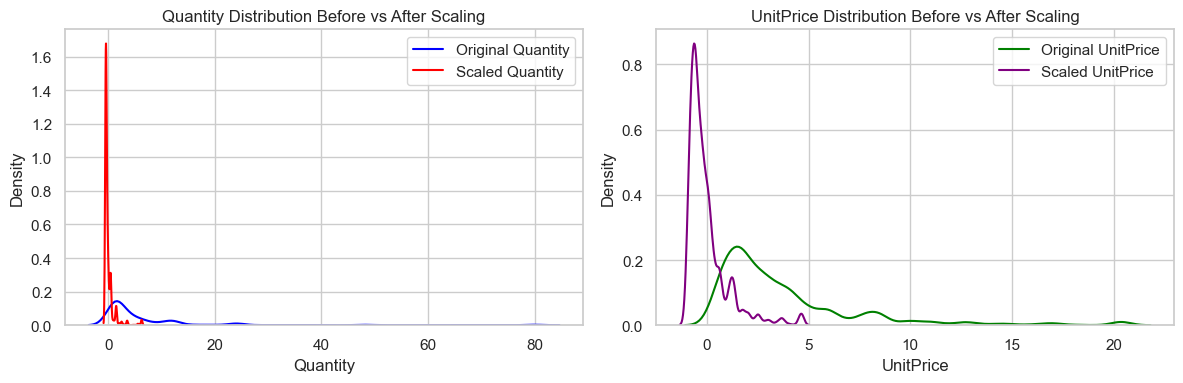

Scaled Numerical Features Summary:


,Quantity_Scaled,UnitPrice_Scaled
count,24078.00,24078.00
mean,0.00,0.00
std,1.00,1.00
min,-0.49,-0.94
25%,-0.49,-0.64
50%,-0.40,-0.33
75%,-0.06,0.15
max,6.26,4.64


In [7]:
scaler = StandardScaler()
df[['Quantity_Scaled', 'UnitPrice_Scaled']] = scaler.fit_transform(df[['Quantity', 'UnitPrice']])

# Visual Report: Feature distribution before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df['Quantity'], ax=axes[0], color='blue', label='Original Quantity')
sns.kdeplot(df['Quantity_Scaled'], ax=axes[0], color='red', label='Scaled Quantity')
axes[0].set_title('Quantity Distribution Before vs After Scaling')
axes[0].legend()

sns.kdeplot(df['UnitPrice'], ax=axes[1], color='green', label='Original UnitPrice')
sns.kdeplot(df['UnitPrice_Scaled'], ax=axes[1], color='purple', label='Scaled UnitPrice')
axes[1].set_title('UnitPrice Distribution Before vs After Scaling')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Scaled Numerical Features Summary:")
display(df[['Quantity_Scaled', 'UnitPrice_Scaled']].describe().round(2))

### 7. Clean Dataset Export
Exporting the fully preprocessed dataset to CSV.

In [8]:
# Save preprocessed dataset
export_path1 = 'data/cleaned_ecommerce_data.csv' if os.path.exists('data') else 'Task-01-Data-Cleaning-and-Visualization/data/cleaned_ecommerce_data.csv'
export_path2 = 'data/cleaned_superstore_sales.csv' if os.path.exists('data') else 'Task-01-Data-Cleaning-and-Visualization/data/cleaned_superstore_sales.csv'

df.to_csv(export_path1, index=False)
df.to_csv(export_path2, index=False)

print(f"Preprocessed dataset saved successfully to: {export_path1}")
print("Final Preprocessed Shape:", df.shape)
print("Total Remaining Missing Values:", df.isnull().sum().sum())

Preprocessed dataset saved successfully to: data/cleaned_ecommerce_data.csv
Final Preprocessed Shape: (24078, 14)
Total Remaining Missing Values: 0


### Summary of Preprocessing Steps Performed
- **Duplicates:** Detected and removed 352 exact duplicate rows.
- **Missing Values:** Imputed missing descriptions (`'Unknown'`) and missing customer IDs (`0`).
- **Data Cleansing:** Converted dates to `datetime` and removed negative/cancelled records.
- **Outlier Handling:** Detected outliers via IQR and capped extreme values at the 1st and 99th percentiles.
- **Categorical Encoding:** Applied One-Hot Encoding to categorical column `Country`.
- **Feature Scaling:** Scaled numerical features (`Quantity`, `UnitPrice`) using `StandardScaler` (Mean = 0.0, Std = 1.0).